In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

# Load datasets
train_data = pd.read_csv("train_data_cl_v2.csv")
test_data = pd.read_csv("test_data_cl_v2.csv")
ground_truth = pd.read_csv("test_data_GroundTruth_cl.csv")

In [2]:
#tampilkan data train
print(train_data)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
707          886         0       3   
708          887         0       2   
709          888         1       1   
710          890         1       1   
711          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [3]:
#tampilkan data test
print(test_data)

     PassengerId  Pclass                                             Name  \
0            892       3                                 Kelly, Mr. James   
1            893       3                 Wilkes, Mrs. James (Ellen Needs)   
2            894       2                        Myles, Mr. Thomas Francis   
3            895       3                                 Wirz, Mr. Albert   
4            896       3     Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
..           ...     ...                                              ...   
326         1301       3                        Peacock, Miss. Treasteall   
327         1303       1  Minahan, Mrs. William Edward (Lillian E Thorpe)   
328         1304       3                   Henriksson, Miss. Jenny Lovisa   
329         1306       1                     Oliva y Ocana, Dona. Fermina   
330         1307       3                     Saether, Mr. Simon Sivertsen   

        Sex   Age  SibSp  Parch              Ticket      Fare Cabin Embarke

In [4]:
# tampilkan data ground truth
print(ground_truth)

     PassengerId  Survived
0            892         0
1            893         1
2            894         0
3            895         0
4            896         1
..           ...       ...
326         1301         1
327         1303         1
328         1304         1
329         1306         1
330         1307         0

[331 rows x 2 columns]


In [5]:
# menampilkan seluruh missing vallue pada ke 3 data
print('Train Data missing value')
print(train_data.isnull().sum())
print('Test Data missing value')
print(test_data.isnull().sum())
print('Ground Truth Data missing value')
print(ground_truth.isnull().sum())

Train Data missing value
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         0
dtype: int64
Test Data missing value
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          244
Embarked         0
dtype: int64
Ground Truth Data missing value
PassengerId    0
Survived       0
dtype: int64


In [6]:
# penanganan missing vallue Serta pemilihan feature, mungkin drop nama, cabin, age, tapi ntar lah nyoba eksperimen make cabin nya di replace unique value
train_data = train_data.drop(['Name', 'Ticket'], axis=1)
test_data = test_data.drop(['Name', 'Ticket'], axis=1)

# Penanganan Missing Values
if "Cabin" in train_data.columns:
    train_data['Cabin'].fillna('Unknown', inplace=True)
    test_data['Cabin'].fillna('Unknown', inplace=True)

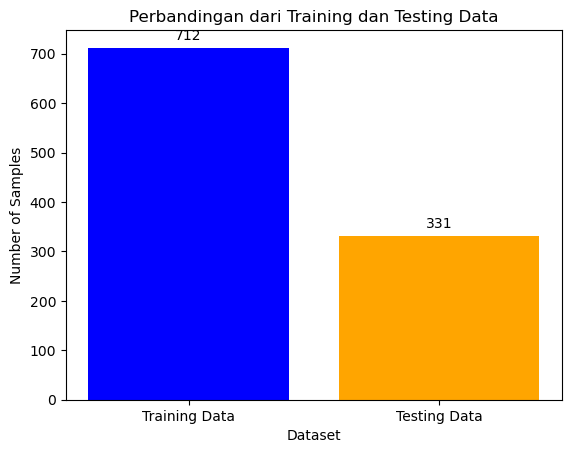

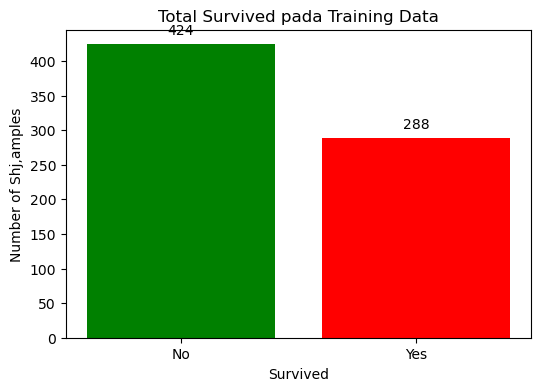

In [7]:
# Visualisasi compare dari training dan testing data
train_count = train_data.shape[0]
test_count = test_data.shape[0]

plt.bar(['Training Data', 'Testing Data'], [train_count, test_count], color=['blue', 'orange'])
plt.xlabel('Dataset')
plt.ylabel('Number of Samples')
plt.title('Perbandingan dari Training dan Testing Data')

for i, count in enumerate([train_count, test_count]):
    plt.text(i, count + 10, str(count), ha='center', va='bottom')

plt.show()

# Visualisasi distribusi 'Survived' pada training data
survived_counts = train_data['Survived'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(survived_counts.index, survived_counts.values, color=['green', 'red'])
plt.xlabel('Survived')
plt.ylabel('Number of Shj,amples')
plt.title('Total Survived pada Training Data')
plt.xticks([0, 1], ['No', 'Yes'])

for i, count in enumerate(survived_counts.values):
    plt.text(i, count + 10, str(count), ha='center', va='bottom')

plt.show()

C:\Users\waisl\AppData\Local\Temp\ipykernel_16092\433095425.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = train_data.corr()


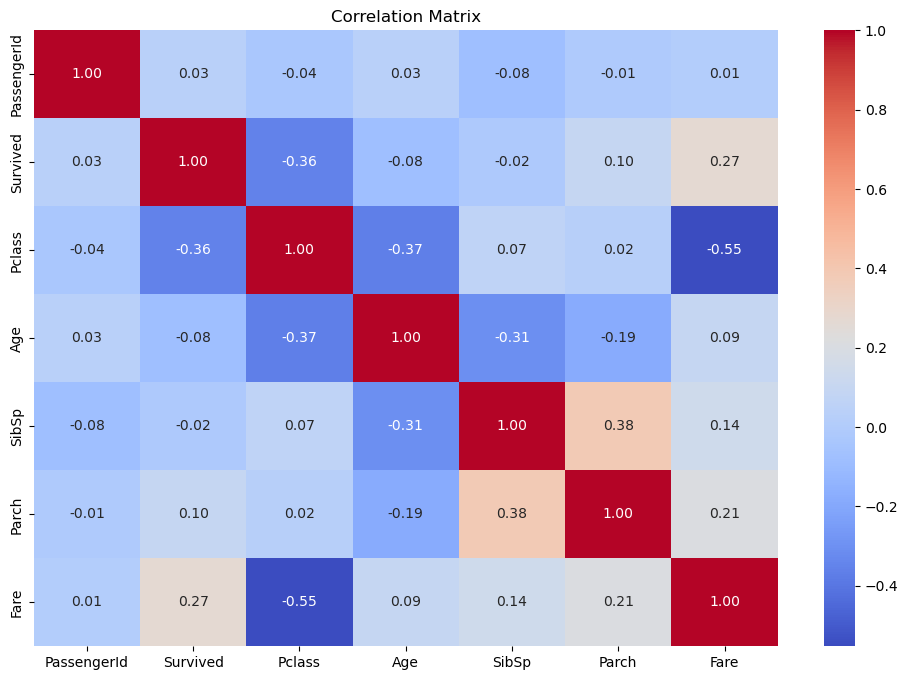

In [8]:
# Person Correlation Coefficient - Menampilkan pengaruh feature lain terhadap 'Survived'
corr_matrix = train_data.corr()
corr_matrix['Survived'].sort_values(ascending=False)

# tampilkan heatmap
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [9]:
# model single layer perceptron tanpa library
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = self._unit_step_func
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        y_ = np.array([1 if i > 0 else 0 for i in y])

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)

                # Perceptron update rule
                update = self.lr * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation_func(linear_output)
        return y_predicted

    def _unit_step_func(self, x):
        return np.where(x >= 0, 1, 0)